## Tomato Pollination: Tomato 2

In [1]:
import numpy as np
import dismech
import os

plant_name = "tomato2"

position = "4"

geom = dismech.GeomParams(
    rod_r0=0.03,
    shell_h=0.0,
)

material = dismech.Material(density=1100,
                            youngs_rod=2.16e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

dyn_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=True,   # no twisting
                                  use_mid_edge=False,
                                  use_line_search=False,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=50,
                                  total_time=5,
                                  plot_step=10,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2
                                  )

env = dismech.Environment()
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
env.add_force('damping', eta=100)

input_txt = os.path.join('../tests/resources/tomato_pollination/plants/', f"{plant_name}.txt")
geo = dismech.Geometry.from_txt(input_txt)

robot = dismech.SoftRobot(geom, material, geo, dyn_sim, env)

### Move the stem: Moving BC

In [2]:
# # --- pick the main grip node robustly ---
# grasping_point = np.array([
#       1.1154284,
#       0.0092739,
#       0.4896594
#     ])
# xyz = robot.state.q[robot.node_dof_indices].reshape(-1, 3)

main_grip = 33  # node at the main grip

print("Main grip node:", main_grip)

other_grip_nodes_below = np.array(range(main_grip-4, main_grip), dtype=int)
other_grip_nodes_above = np.arange(main_grip+4, main_grip, -1, dtype=int)

print("Other grip nodes below:", other_grip_nodes_below)
print("Other grip nodes above:", other_grip_nodes_above)

Main grip node: 33
Other grip nodes below: [29 30 31 32]
Other grip nodes above: [37 36 35 34]


In [3]:
base_nodes = np.where((robot.state.q[robot.node_dof_indices].reshape(-1, 3)[:, 2]) < 0.22)[0] # fixed base
# Fix only main_grip and base nodes
robot = robot.fix_nodes(np.unique(np.r_[main_grip, base_nodes]))

In [4]:
# ----- once, before simulation -----

all_grip_nodes = np.r_[main_grip, other_grip_nodes_below, other_grip_nodes_above].astype(int)

xyz0 = robot.state.q[robot.node_dof_indices].reshape(-1, 3).copy()
x0 = xyz0[all_grip_nodes, 0].copy()          # initial x of all prescribed nodes
prev_target_x = x0.copy()                     # last absolute target (starts at initial)

# (Optional) precompute amplitude scalings from *initial* geometry
def build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main):
    amps = np.empty(all_grip_nodes.size, float)
    amps[0] = A_main  # main_grip
    # below group
    below = np.array(other_grip_nodes_below, dtype=int)
    if below.size:
        ref = below[0]
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(below, start=1):  # start=1 because 0 is main_grip
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    # above group
    above = np.array(other_grip_nodes_above, dtype=int)
    if above.size:
        ref = above[0]
        offset = 1 + below.size
        L = max(np.linalg.norm(xyz0[main_grip]-xyz0[ref]), 1e-12)
        for j, node in enumerate(above, start=offset):
            amps[j] = A_main * (np.linalg.norm(xyz0[ref]-xyz0[node]) / L)
    return amps

A_main = 0.340670063e-2   # m at main_grip
freq   = 1.3    # Hz
amps   = build_amps_from_xyz0(xyz0, main_grip, all_grip_nodes, A_main)

def shake_distributed(robot, t: float):
    # absolute target centered at initial pose
    target_x = x0 + amps * np.sin(2*np.pi*freq*t)

    # INCREMENT ONLY: avoids velocity spikes and keeps symmetry
    delta_x = target_x - prev_target_x
    prev_target_x[:] = target_x

    return robot.move_nodes(all_grip_nodes, delta_x.reshape(-1,1).flatten(), axis=0)

print("grasping points:", all_grip_nodes)

grasping points: [33 29 30 31 32 37 36 35 34]


In [5]:
stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = shake_distributed

### Simulate

In [6]:
# simulate
robots = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])

iter: 1, error: 8255.541
iter: 2, error: 187.906
current_time:  0.01
iter: 1, error: 8193.377
iter: 2, error: 72.763
current_time:  0.02
iter: 1, error: 8083.292
iter: 2, error: 79.325
current_time:  0.03
iter: 1, error: 7924.704
iter: 2, error: 79.812
current_time:  0.04
iter: 1, error: 7715.163
iter: 2, error: 74.045
current_time:  0.05
iter: 1, error: 7453.270
iter: 2, error: 65.990
current_time:  0.06
iter: 1, error: 7139.770
iter: 2, error: 58.082
current_time:  0.07
iter: 1, error: 6777.052
iter: 2, error: 51.039
current_time:  0.08
iter: 1, error: 6368.265
iter: 2, error: 44.720
current_time:  0.09
iter: 1, error: 5916.693
iter: 2, error: 38.697
current_time:  0.1
iter: 1, error: 5425.534
iter: 2, error: 32.681
current_time:  0.11
iter: 1, error: 4897.973
iter: 2, error: 26.652
current_time:  0.12
iter: 1, error: 4337.332
iter: 2, error: 20.800
current_time:  0.13
iter: 1, error: 3747.193
iter: 2, error: 15.384
current_time:  0.14
iter: 1, error: 3131.420
iter: 2, error: 10.625


### Plotting

In [7]:
t = np.arange(robot.sim_params.total_time, step=robot.sim_params.dt)
options = dismech.AnimationOptions(title='Tomato2', plot_step=10)

fig = dismech.get_interactive_animation_plotly(robot, t, qs , options)
fig.show()

In [8]:
# # save gif
# ani = dismech.get_animation(robot, t, qs, options)
# save_path = os.path.join("tomato_results", f"{plant_name}_{position}.gif")
# ani.save(save_path)


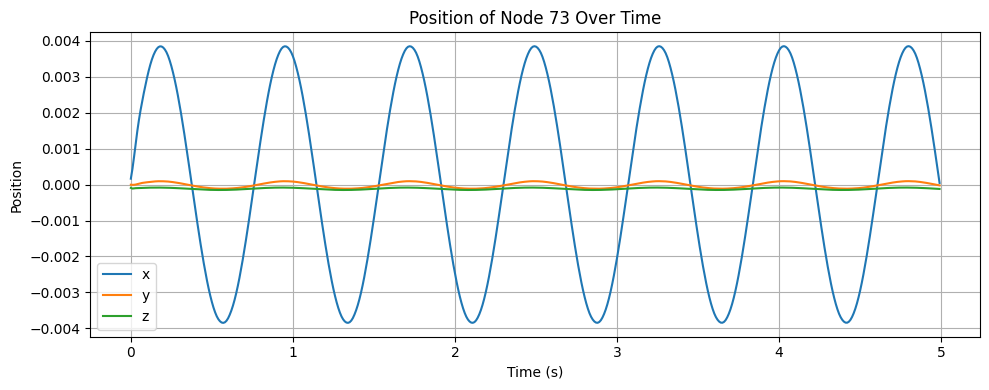

In [9]:
# plot the trajectory of the flower location
flower_node = 73  # pick a node at the flower

import matplotlib.pyplot as plt

# Extract the DOF indices (x, y, z) of the node you want to track
flower_node_dofs = robot.map_node_to_dof(flower_node)  # e.g., [ix, iy, iz]

# Extract position of that node across all timesteps
logged = qs[:, flower_node_dofs].squeeze()  # shape (n_timesteps, 3)

# remove value at t=0
logged -= robot.nodes[flower_node]

# Plot x, y, z over time
t = np.arange(qs.shape[0]) * robot.sim_params.dt

plt.figure(figsize=(10, 4))
plt.plot(t, logged[:, 0], label='x')
plt.plot(t, logged[:, 1], label='y')
plt.plot(t, logged[:, 2], label='z')
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title(f'Position of Node {flower_node} Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Save data for rendering

In [10]:
# from dismech.logging import logDataForRendering
# from dismech.logging import export_parachute_data

# rod_data, shell_data = logDataForRendering(qs, t.reshape(-1, 1), robot, len(t), robot.sim_params.static_sim, robot.map_node_to_dof)

# js_file = os.path.join("tomato_results", f"{plant_name}_{position}.js")
# export_parachute_data(qs, geo.rod_edges, robot,
#                           rod_js=js_file,
#                           scaleFactor=100)

In [11]:
import numpy as np
from scipy.signal import hilbert, detrend, find_peaks

def avg_cycle_amplitude_hilbert(x: np.ndarray) -> float:
    """
    Robust average oscillation amplitude using the analytic-signal envelope.
    Returns the median envelope value (less sensitive to outliers).
    """
    x = np.asarray(x).ravel()
    x = detrend(x)  # remove slow drift
    envelope = np.abs(hilbert(x))
    # Use median to resist occasional spikes; mean is also fine.
    return float(np.median(envelope))

In [12]:
# amplitude of flower node motion
amp_x_flower_hilbert = avg_cycle_amplitude_hilbert(logged[:, 0]) # hilbert-based amplitude
amp_x_flower_peak = (np.max(logged[:, 0]) - np.min(logged[:, 0])) / 2.0 # peak-to-peak amplitude
print(f"Amplitude of flower node {flower_node} motion in x (peak-to-peak): {amp_x_flower_peak:.4f} m")
print(f"Amplitude of flower node {flower_node} motion in x (hilbert): {amp_x_flower_hilbert:.4f} m")

Amplitude of flower node 73 motion in x (peak-to-peak): 0.0039 m
Amplitude of flower node 73 motion in x (hilbert): 0.0039 m


#### Estimate frequency

In [13]:
import numpy as np

def estimate_frequency(signal, dt):
    """
    Estimate dominant frequency of a periodic signal using FFT.
    
    Parameters
    ----------
    signal : 1D np.ndarray
        The time-varying signal (samples).
    dt : float
        Time step between samples.
    
    Returns
    -------
    freq : float
        Dominant frequency (Hz).
    """
    n = len(signal)
    # Remove mean to avoid 0 Hz dominance
    signal = signal - np.mean(signal)

    # FFT
    freqs = np.fft.rfftfreq(n, d=dt)       # frequency bins (Hz)
    fft_vals = np.fft.rfft(signal)         # FFT coefficients
    magnitude = np.abs(fft_vals)

    # Find the peak frequency (excluding DC = 0 Hz)
    peak_idx = np.argmax(magnitude[1:]) + 1
    freq = freqs[peak_idx]
    return freq


# Example: make a sine wave of 5 Hz, sample at 100 Hz

f_est = estimate_frequency(logged[:, 0], robot.sim_params.dt)
print(f"Estimated frequency: {f_est:.2f} Hz")   # ~5.00 Hz


Estimated frequency: 1.20 Hz
